<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/4_Valores_at%C3%ADpicos_DataFrame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
data= pd.read_csv('Análisis_de_Piso_Sin_Nulos.csv') 

In [3]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Asesor       41 non-null     str    
 1   feb          41 non-null     float64
 2   mar          41 non-null     float64
 3   abr          41 non-null     float64
 4   may          41 non-null     float64
 5   jun          41 non-null     float64
 6   jul          41 non-null     float64
 7   ago          41 non-null     float64
 8   sep          41 non-null     str    
 9   oct          41 non-null     float64
 10  nov          41 non-null     float64
 11  dic          41 non-null     float64
 12  ene          41 non-null     float64
 13  feb.1        41 non-null     float64
 14  mar.1        41 non-null     float64
 15  abr.1        41 non-null     float64
 16               41 non-null     int64  
 17   .1          41 non-null     int64  
 18  Unnamed: 18  41 non-null     float64
 19  Unnamed: 19  41 non-n

In [4]:
#Revisamos los valores únicos de las columnas que aparecen como str

print("Valores de sep:")
print(data["sep"].unique())

print("\nValores de feb.2:")
print(data["feb.2"].unique())

print("\nValores de abr.3:")
print(data["abr.3"].unique())

Valores de sep:
<StringArray>
['0', ' ', '1', '8', '9', '16', '5', '2', '59']
Length: 9, dtype: str

Valores de feb.2:
<StringArray>
[' ', '2', '1', '9']
Length: 4, dtype: str

Valores de abr.3:
<StringArray>
[' ', '1', '2', '4']
Length: 4, dtype: str


In [6]:
#Seleccionamos todas las columnas excepto Asesor

columnas_numericas = data.columns.drop("Asesor ")

#Sustituimos los espacios vacíos por 0

data[columnas_numericas] = data[columnas_numericas].replace(
    r"^\s*$",
    0,
    regex=True
)

#Convertimos todas las columnas a float

data[columnas_numericas] = (
    data[columnas_numericas]
    .apply(pd.to_numeric, errors="coerce")
    .astype(float)
)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Asesor       41 non-null     str    
 1   feb          41 non-null     float64
 2   mar          41 non-null     float64
 3   abr          41 non-null     float64
 4   may          41 non-null     float64
 5   jun          41 non-null     float64
 6   jul          41 non-null     float64
 7   ago          41 non-null     float64
 8   sep          41 non-null     float64
 9   oct          41 non-null     float64
 10  nov          41 non-null     float64
 11  dic          41 non-null     float64
 12  ene          41 non-null     float64
 13  feb.1        41 non-null     float64
 14  mar.1        41 non-null     float64
 15  abr.1        41 non-null     float64
 16               41 non-null     float64
 17   .1          41 non-null     float64
 18  Unnamed: 18  41 non-null     float64
 19  Unnamed: 19  41 non-n

In [8]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

Asesor         0
feb            0
mar            0
abr            0
may            0
jun            0
jul            0
ago            0
sep            0
oct            0
nov            0
dic            0
ene            0
feb.1          0
mar.1          0
abr.1          0
               0
 .1            0
Unnamed: 18    0
Unnamed: 19    0
feb.2          0
mar.2          0
abr.2          0
may.1          0
jun.1          0
jul.1          0
ago.1          0
sep.1          0
oct.1          0
nov.1          0
dic.1          0
ene.1          0
feb.3          0
mar.3          0
abr.3          0
May            0
Junio          0
dtype: int64

In [9]:
#Variables cuantitativas: columnas 1 a 36
cuantitativas = data.iloc[:, 1:37]

#Variable cualitativa: columna 0
cualitativas = data.iloc[:, [0]]

<Figure size 1500x800 with 0 Axes>

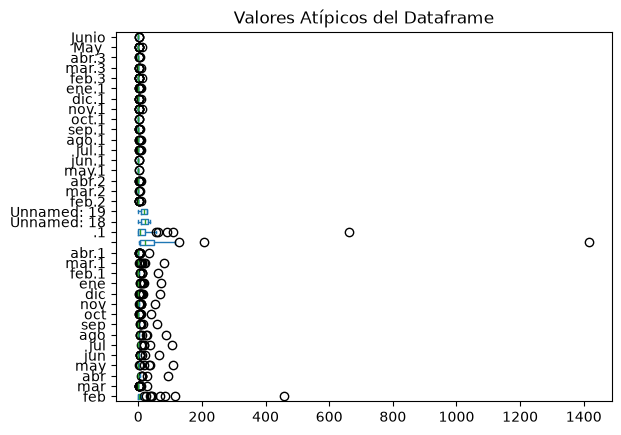

In [10]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

**Excluimos la fila de "Asesor no identificado" porque es una categoría acumulada**

In [12]:
#Localizamos la fila del asesor no identificado
data[
    data["Asesor "].str.contains(
        "no identificado",
        case=False,
        na=False
    )
]

,Asesor,feb,mar,abr,may,jun,jul,ago,sep,oct,...,sep.1,oct.1,nov.1,dic.1,ene.1,feb.3,mar.3,abr.3,May,Junio
40,Asesor no identificado,459.0,27.0,95.0,110.0,65.0,107.0,88.0,59.0,40.0,...,6.0,3.0,11.0,8.0,10.0,12.0,9.0,4.0,12.0,3.0


In [14]:
#Creamos un dataframe sin el asesor no identificado

data_asesores = data[
    ~data["Asesor "].str.contains(
        "no identificado",
        case=False,
        na=False
    )
].copy()

In [15]:
#Variables cuantitativas

cuantitativas = data_asesores.iloc[:, 1:]

#Variable cualitativa

cualitativas = data_asesores.iloc[:, [0]]

<Figure size 1500x800 with 0 Axes>

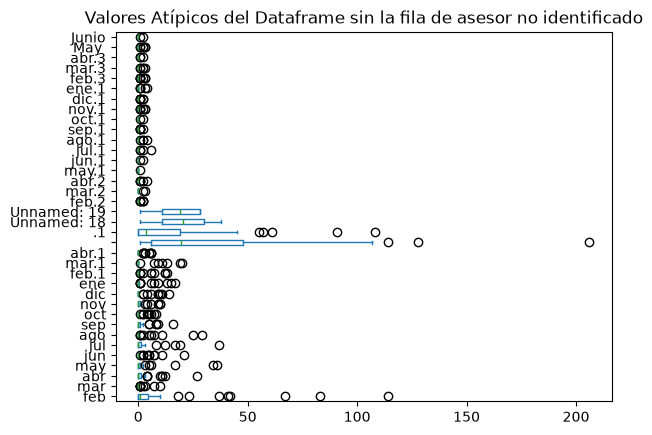

In [17]:
#Checar el diagrama de caja o bigote con los nuevos valores reemplazados
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe sin la fila de asesor no identificado")
plt.show() #dibujamos el diagrama

**PROCEDIMIENTO "DESVIACIÓN ESTÁNDAR" PARA ELIMINAR OUTLIERS EN DATAFRAME**

In [18]:
#Método aplicando desviación estandar. Encuentro los valores extremos
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido feb             87.351380
mar              6.534411
abr             17.995807
may             26.881849
jun             13.676572
jul             24.033344
ago             20.869597
sep             11.551343
oct              7.516252
nov              9.460038
dic             12.700582
ene             14.727354
feb.1           12.180172
mar.1           17.357283
abr.1            6.402031
               166.287031
 .1             95.032190
Unnamed: 18     54.688688
Unnamed: 19     45.856130
feb.2            1.955385
mar.2            1.814902
abr.2            2.425087
may.1            0.499342
jun.1            1.124725
jul.1            3.269170
ago.1            2.527591
sep.1            1.430024
oct.1            1.124725
nov.1            2.526922
dic.1            1.749193
ene.1            2.675823
feb.3            2.573594
mar.3            2.204219
abr.3            1.236797
May              2.672924
Junio            1.124725
dtype: float64
Limite inferior permiti

In [19]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data1= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data1

,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,...,sep.1,oct.1,nov.1,dic.1,ene.1,feb.3,mar.3,abr.3,May,Junio
0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,NaN,NaN,1.0,2.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,0.0,...,0.0,NaN,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN
4,0.0,0.0,0.0,2.0,0.0,0.0,2.0,8.0,4.0,NaN,...,NaN,0.0,NaN,1.0,0.0,NaN,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,18.0,NaN,NaN,NaN,11.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,0.0,3.0,3.0,2.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [20]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data1.isnull().sum()
valores_nulos

feb            1
mar            2
abr            1
may            2
jun            1
jul            1
ago            2
sep            1
oct            1
nov            2
dic            1
ene            2
feb.1          1
mar.1          2
abr.1          0
               1
 .1            1
Unnamed: 18    0
Unnamed: 19    0
feb.2          3
mar.2          2
abr.2          1
may.1          1
jun.1          1
jul.1          1
ago.1          1
sep.1          1
oct.1          1
nov.1          2
dic.1          2
ene.1          2
feb.3          2
mar.3          1
abr.3          1
May            2
Junio          1
dtype: int64

In [22]:
#Reemplazamos valores atípicos (nulos) del dataframe con "median"
#Realizamos una copia del dataframe
data_clean=data1.copy()
data_clean=data_clean.fillna(data1.median().round(0))
data_clean

,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,...,sep.1,oct.1,nov.1,dic.1,ene.1,feb.3,mar.3,abr.3,May,Junio
0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,2.0,0.0,0.0,2.0,8.0,4.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,18.0,0.0,0.0,0.0,11.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,0.0,3.0,3.0,2.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [23]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum()
valores_nulos

feb            0
mar            0
abr            0
may            0
jun            0
jul            0
ago            0
sep            0
oct            0
nov            0
dic            0
ene            0
feb.1          0
mar.1          0
abr.1          0
               0
 .1            0
Unnamed: 18    0
Unnamed: 19    0
feb.2          0
mar.2          0
abr.2          0
may.1          0
jun.1          0
jul.1          0
ago.1          0
sep.1          0
oct.1          0
nov.1          0
dic.1          0
ene.1          0
feb.3          0
mar.3          0
abr.3          0
May            0
Junio          0
dtype: int64

**PROCEDIMIENTO "CUANTILES" PARA SUSTITUIR OUTLIERS EN DATAFRAME**

In [24]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido feb             11.250
mar              0.000
abr              3.125
may              2.500
jun              0.625
jul              3.125
ago              0.625
sep              2.500
oct              0.000
nov              2.500
dic              0.000
ene              0.625
feb.1            0.625
mar.1            0.000
abr.1            0.000
               111.375
 .1             47.500
Unnamed: 18     59.500
Unnamed: 19     53.875
feb.2            0.000
mar.2            0.000
abr.2            0.000
may.1            0.000
jun.1            0.000
jul.1            0.000
ago.1            0.000
sep.1            0.000
oct.1            0.000
nov.1            0.000
dic.1            0.000
ene.1            0.000
feb.3            0.000
mar.3            0.000
abr.3            0.000
May              0.000
Junio            0.000
dtype: float64
Limite inferior permitido feb            -6.750
mar             0.000
abr            -1.875
may            -1.500
jun            -0

In [25]:
#Obtenemos datos limpios del Dataframe
data1_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data1_iqr

,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,...,sep.1,oct.1,nov.1,dic.1,ene.1,feb.3,mar.3,abr.3,May,Junio
0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,0.0,...,0.0,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN
4,0.0,0.0,0.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
6,NaN,NaN,NaN,NaN,NaN,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,0.0,3.0,NaN,NaN,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.0


In [26]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data1_iqr.isnull().sum()
valores_nulos

feb             8
mar             9
abr             8
may             6
jun            10
jul             5
ago            10
sep             6
oct             9
nov             6
dic             9
ene            10
feb.1          10
mar.1           7
abr.1           9
                3
 .1             5
Unnamed: 18     0
Unnamed: 19     0
feb.2           6
mar.2           2
abr.2           5
may.1           1
jun.1           2
jul.1           4
ago.1           4
sep.1           5
oct.1           2
nov.1           6
dic.1           6
ene.1           5
feb.3           7
mar.3           5
abr.3           3
May             6
Junio           2
dtype: int64

In [27]:
#Reemplazamos valores atípicos (nulos) del dataframe con "median
#Realizamos una copia del dataframe
data2_iqr=data1_iqr.copy()
data2_iqr=data2_iqr.fillna(round(data1_iqr.median(),0))
data2_iqr

,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,...,sep.1,oct.1,nov.1,dic.1,ene.1,feb.3,mar.3,abr.3,May,Junio
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data2_iqr], axis=1)
Datos_limpios

,Asesor,feb,mar,abr,may,jun,jul,ago,sep,oct,...,sep.1,oct.1,nov.1,dic.1,ene.1,feb.3,mar.3,abr.3,May,Junio
0,ABIGAIL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ALAN GONZALES,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ALICIA LEDESMA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AURELIO FELIPE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CARLOS ALBERTO NIETO,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,CARLOS TEXIS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,CARLOS MANUEL CARMONA,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,CINTYA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,CLAUDIA GALVAN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,CASA,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Asesor         0
feb            0
mar            0
abr            0
may            0
jun            0
jul            0
ago            0
sep            0
oct            0
nov            0
dic            0
ene            0
feb.1          0
mar.1          0
abr.1          0
               0
 .1            0
Unnamed: 18    0
Unnamed: 19    0
feb.2          0
mar.2          0
abr.2          0
may.1          0
jun.1          0
jul.1          0
ago.1          0
sep.1          0
oct.1          0
nov.1          0
dic.1          0
ene.1          0
feb.3          0
mar.3          0
abr.3          0
May            0
Junio          0
dtype: int64

In [30]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Análisis_De_Piso_Sin_Atípicos.csv")